<a href="https://colab.research.google.com/github/sirishan506-source/google-collab/blob/main/winequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup & Data Loading
First, let’s import libraries and load the dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import kagglehub
import os

In [3]:
# Download latest version
path = kagglehub.dataset_download("anairamcosta/winequality-red-csv")

print("Path to dataset files:", path)

100%|██████████| 25.6k/25.6k [00:00<00:00, 23.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/anairamcosta/winequality-red-csv/versions/1


In [4]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "winequality-red.csv")

print("Path to CSV file:", csv_file_path)

# Load the dataset
data = pd.read_csv(csv_file_path,
                   delimiter=',',
                   header=0,
                   engine='python')


Path to CSV file: /root/.cache/kagglehub/datasets/anairamcosta/winequality-red-csv/versions/1/winequality-red.csv


In [5]:
# Display first 5 rows
print("Dataset Preview:")
display(data.head())

Dataset Preview:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


2. Exploratory Data Analysis (EDA)¶
Let’s analyze distributions, correlations, and missing values.

2.1 Check for Missing Values

In [6]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


2.2 Distribution of Wine Quality

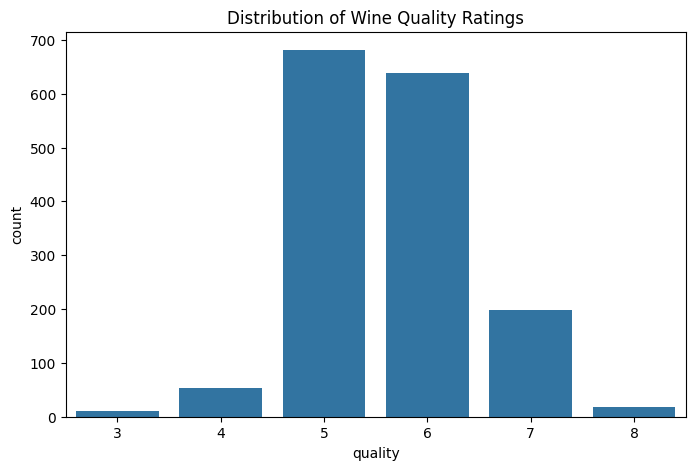

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data)
plt.title("Distribution of Wine Quality Ratings")
plt.show()

2.3 Correlation Heatmap

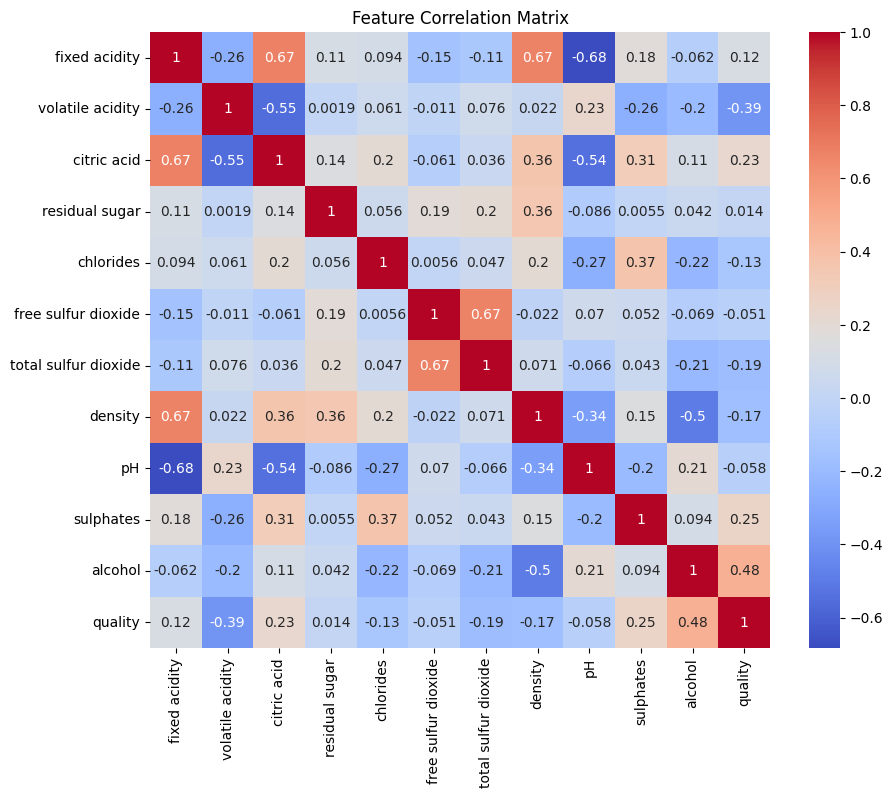

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

3. Data Preprocessing
We’ll:

Convert quality into binary classes (low (≤5) vs. high (≥6)).

Scale features for better model performance.

3.1 Convert Quality to Binary Classes

In [9]:
data['quality_class'] = np.where(data['quality'] >= 6, 1, 0)  # 1 = "High", 0 = "Low"
X = data.drop(['quality', 'quality_class'], axis=1)
y_reg = data['quality']  # For regression
y_clf = data['quality_class']  # For classification

3.2 Split Data into Train & Test Sets

In [10]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

3.3 Feature Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# 3.3 Feature Scaling

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardization
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

# Normalization
normal_scaler = MinMaxScaler()
X_train_normalized = normal_scaler.fit_transform(X_train)
X_test_normalized = normal_scaler.transform(X_test)

4. Machine Learning Models
4.1 Regression: Predicting Quality Scores (Linear Regression & Random Forest)

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
y_pred_reg_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test_reg, y_pred_reg_lr)

# Random Forest Regression
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_reg_rf = rf_reg.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test_reg, y_pred_reg_rf)

print(f"Linear Regression MSE: {mse_lr:.2f}")
print(f"Random Forest Regression MSE: {mse_rf:.2f}")

Linear Regression MSE: 0.39
Random Forest Regression MSE: 0.30


4.2 Classification: High vs. Low Quality (Logistic Regression & Random Forest)

In [13]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train_clf)
y_pred_clf_lr = logreg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test_clf, y_pred_clf_lr)

# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
y_pred_clf_rf = rf_clf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test_clf, y_pred_clf_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.2f}")
print(f"Random Forest Classifier Accuracy: {acc_rf:.2f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test_clf, y_pred_clf_rf))

Logistic Regression Accuracy: 0.74
Random Forest Classifier Accuracy: 0.78

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.76      0.75      0.75       141
           1       0.81      0.81      0.81       179

    accuracy                           0.78       320
   macro avg       0.78      0.78      0.78       320
weighted avg       0.78      0.78      0.78       320



5. Feature Importance Analysis
Let’s see which features most influence wine quality.

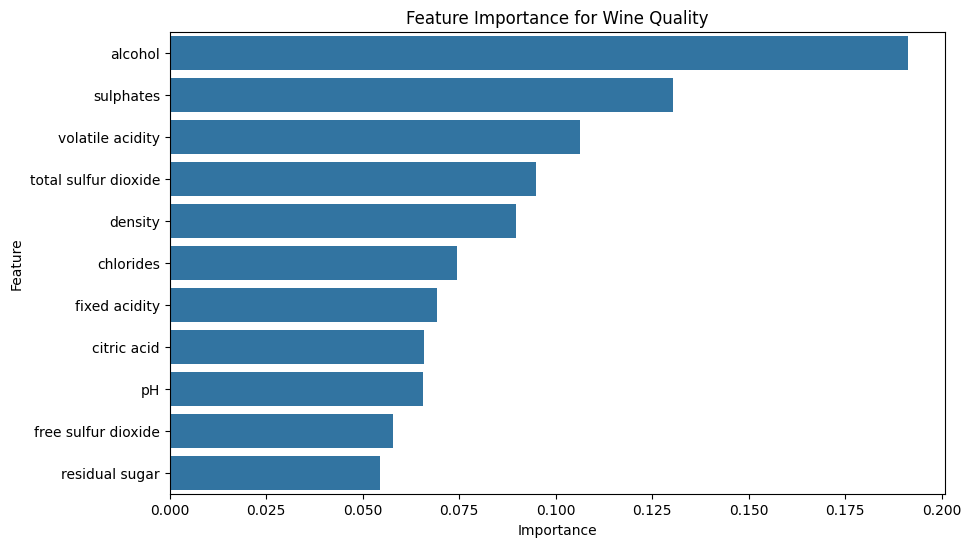

In [14]:
# Plot feature importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance for Wine Quality")
plt.show()

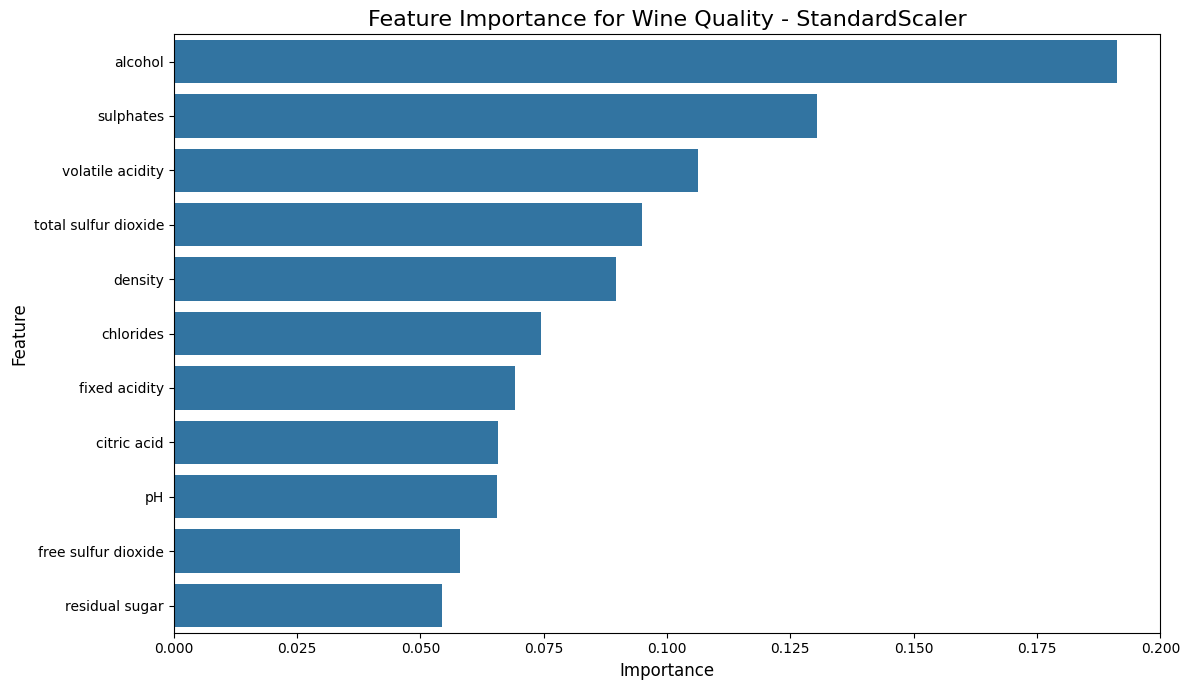

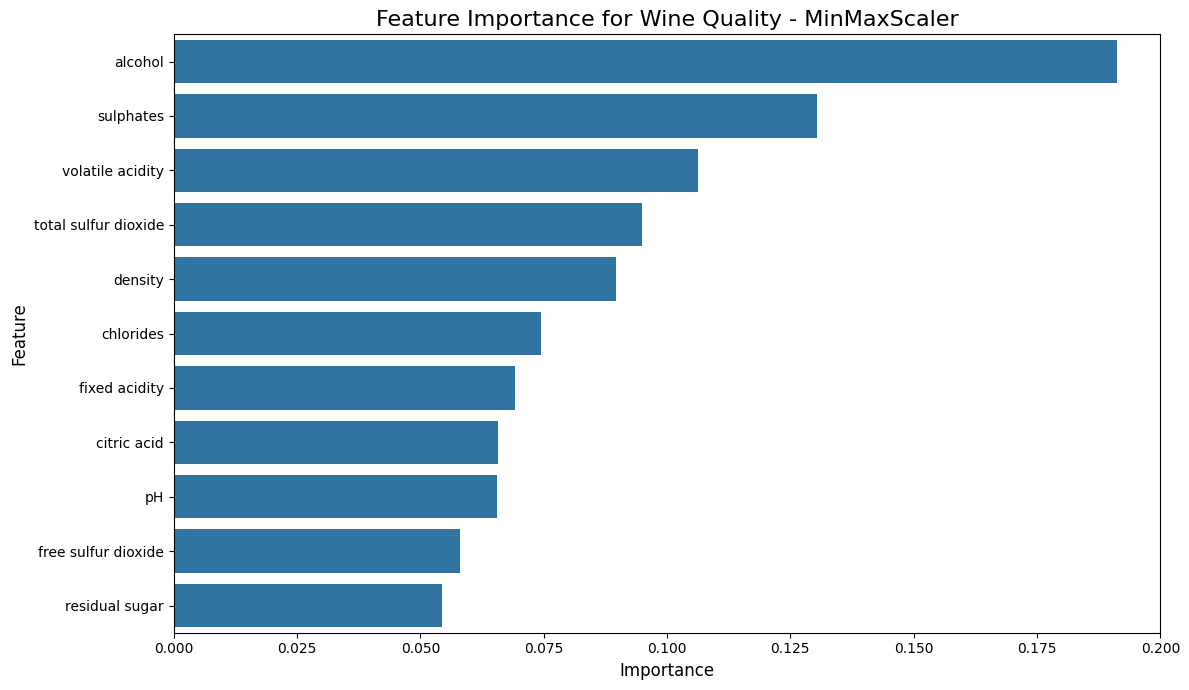

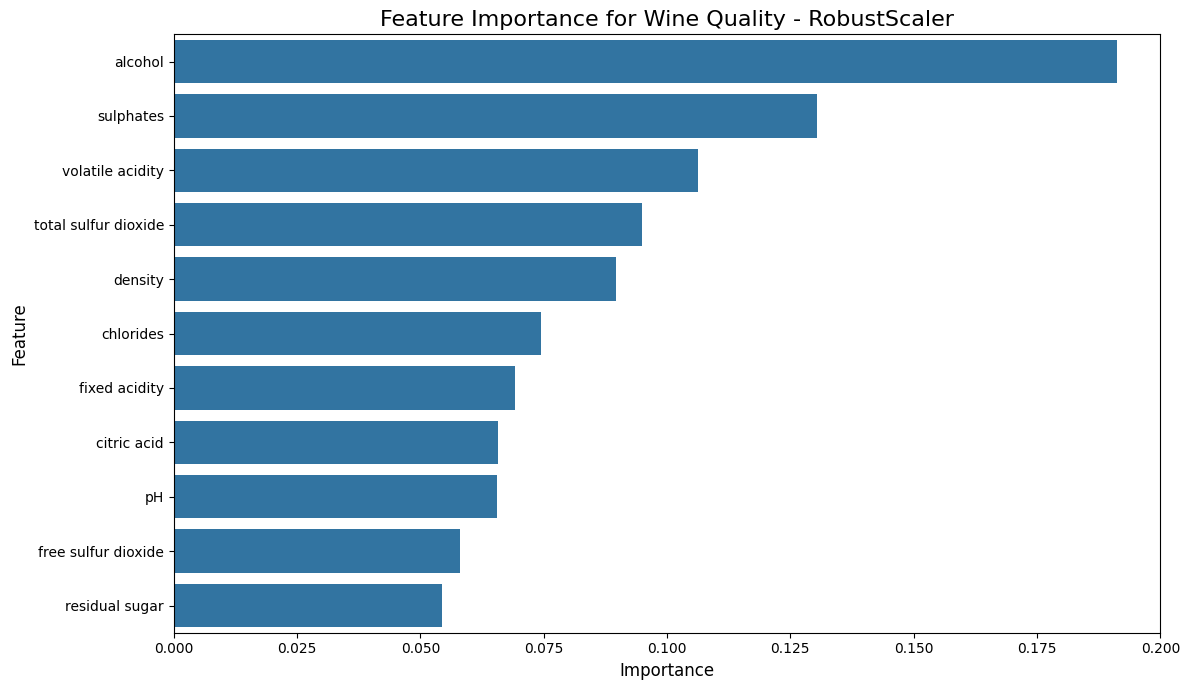

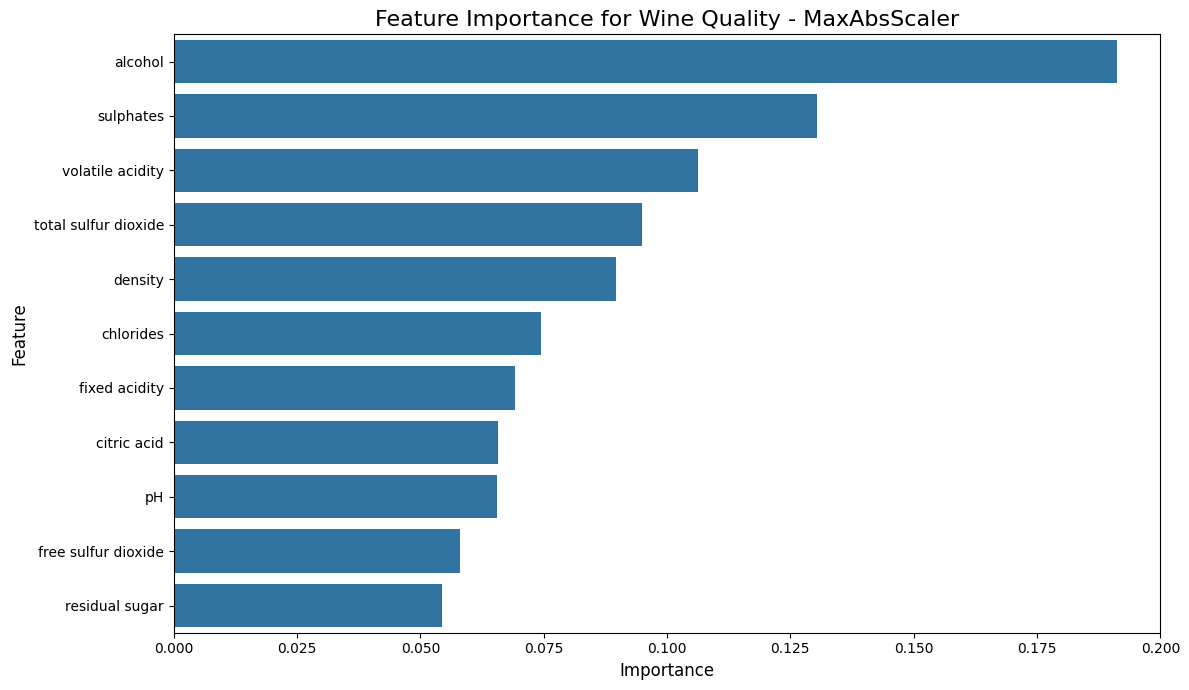

In [24]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler
)

from sklearn.ensemble import RandomForestClassifier


# ---------------------------------------------------------
# Define different scaling techniques
# ---------------------------------------------------------

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler()
}


# ---------------------------------------------------------
# Generate feature importance graph for each scaler
# ---------------------------------------------------------

for scaler_name, scaler in scalers.items():

    # Scale training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Scale testing data
    X_test_scaled = scaler.transform(X_test)

    # Random Forest Classifier
    rf_clf = RandomForestClassifier(
        random_state=42
    )

    # Train model
    rf_clf.fit(X_train_scaled, y_train_clf)

    # Get feature importance
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf_clf.feature_importances_
    })

    # Sort feature importance
    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance
    )

    plt.title(
        f"Feature Importance for Wine Quality - {scaler_name}",
        fontsize=16
    )

    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Feature", fontsize=12)

    plt.xlim(0, 0.20)

    plt.tight_layout()
    plt.show()

MinMaxScaler graph

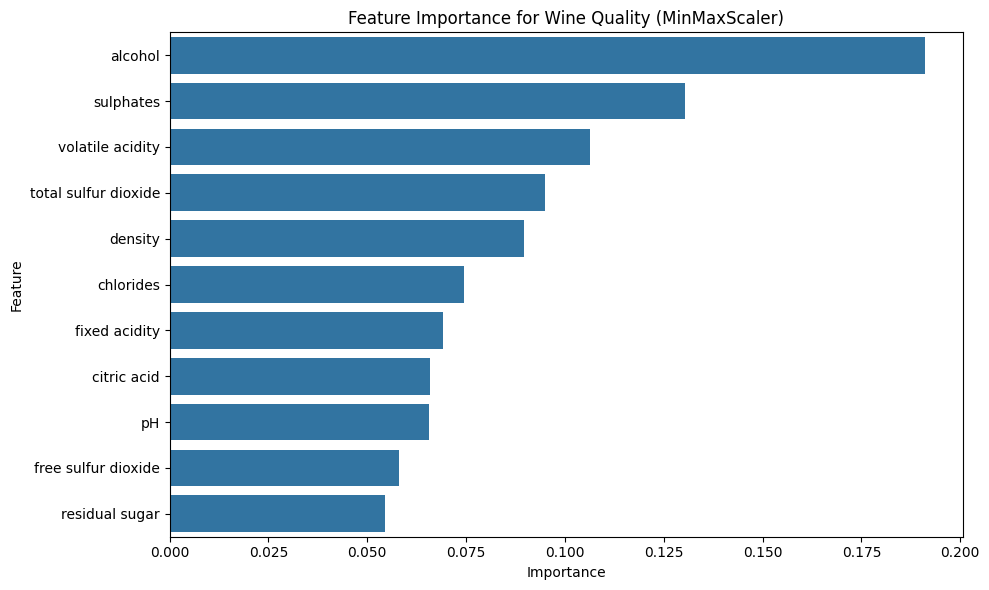

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)

plt.title("Feature Importance for Wine Quality (MinMaxScaler)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

RobustScaler graph


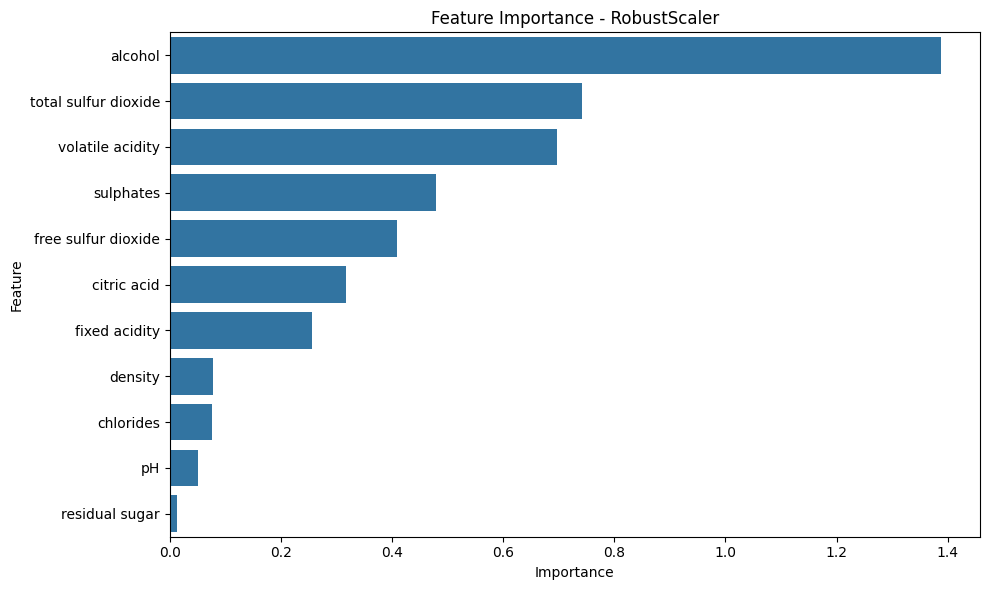

In [27]:
# RobustScaler Feature Importance

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train_clf)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(logreg.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance - RobustScaler")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

MaxAbsScaler graph

In [ ]:
# MaxAbsScaler Feature Importance

from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)*

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train_clf)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(logreg.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance - MaxAbsScaler")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()